In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
from scipy.signal import savgol_filter
import matplotlib.ticker as ticker
from scipy.interpolate import UnivariateSpline
import functions
from functions import shift_spectrum_to_peak
%matplotlib widget
#from BaselineRemoval import BaselineRemoval


#print(matplotlib.matplotlib_fname())  # Prints the path to the loaded matplotlibrc file
#plt.rcParams.update(plt.rcParamsDefault)  # Reset to default settings

def load_XRD_txt(file_path):
    """Loads XRD data from a .txt file."""
    data = np.loadtxt(file_path, comments="#", delimiter=None)
    two_theta = data[:, 0]
    intensity = data[:, 1]
    return two_theta, intensity

def normalize_intensity(intensity):
    """Normalizes intensity to a maximum of 1."""
    return intensity / np.max(intensity)

def moving_average(data, window_size):
    """Applies a moving average filter to the data."""
    window = np.ones(int(window_size)) / float(window_size)
    return np.convolve(data, window, 'same')  # 'same' keeps output the same size

"""def get_cividis_no_yellow(num_colors):
    Returns 'num_colors' colors from cividis, excluding yellow.
    cividis = cm.cividis
    start = 0.0  # Start of the colormap (adjust if needed)
    end = 0.85  # End of the colormap (adjust to cut off yellow)
    new_cmap = ListedColormap(cividis(np.linspace(start, end, 256)))  # Subsample
    return [new_cmap(i) for i in np.linspace(0, 1, num_colors)]"""

def define_colors():
    """Returns a list of colors for plotting."""	
    colors = [
        "#909090",  # light grey
        "#607090",  # greyish blue
        "#4060B0",  # medium blue
        "#2040D0",  # strong blue
        "#0033CC"   # deep blue
    ]
    return colors

def peak_intensity_ratio(two_theta, intensity, peak1=32.5, peak2=17.6, window=0.5):
    """
    Calculates the ratio of the peak intensity between (221) and (120) peaks.
    peak1: position of (221) peak (default 32.5 deg)
    peak2: position of (120) peak (default 17.6 deg)
    window: range around peak position to search for max intensity
    """
    # Find max intensity near each peak
    mask1 = (two_theta >= peak1 - window) & (two_theta <= peak1 + window)
    mask2 = (two_theta >= peak2 - window) & (two_theta <= peak2 + window)
    peak1_int = np.max(intensity[mask1]) if np.any(mask1) else np.nan
    peak2_int = np.max(intensity[mask2]) if np.any(mask2) else np.nan
    if np.isnan(peak1_int) or np.isnan(peak2_int) or peak2_int == 0:
        return np.nan
    return peak1_int / peak2_int
    

In [14]:
def plot_XRD_normalized(*files, labels=None, start_two_theta=5, offset=0, colors=None, window_size=1):
    """Plots multiple normalized XRD spectra."""
    colors = define_colors()

    fig, ax = plt.subplots(figsize=(8, 6)) # Create figure and axes FIRST

    for i, file in enumerate(files):
        two_theta, intensity = load_XRD_txt(file)
        
        # Shift the spectrum to align the FTO peak at 37.9°
        two_theta, shift = shift_spectrum_to_peak(two_theta, intensity, target_peak=37.9, window=0.4, plot=False)
        print(f"2θ shift applied: {shift:.4f} degrees")


        ratio = peak_intensity_ratio(two_theta, intensity)
        print(f"Peak (221)/(120) intensity ratio for {labels[i]}: {ratio}")
        
        plt.plot(two_theta, intensity + (len(files) - i - 1) * offset , label=labels[i], color=colors[i], linewidth=1, linestyle='-')
    
    plt.xlabel("2θ (°)", fontsize=14)
    plt.ylabel("Intensity (a.u.)", fontsize=14)
    plt.grid(alpha=0.3)
    #ax.set_yscale('log') # Now set the log scale on the axes object
    ax.minorticks_on()
    
    #ax.set_yticks([10**i for i in range(-14, 1)])  # Ticks at 10^-14, 10^-13, ..., 10^0
    ax.set_xlim(15, 40)
    ax.set_xticks(np.arange(15, 40, 1))
    ax.set_ylim(5000, 55000)
    #ax.legend(fontsize=12, loc='upper right')
    ax.legend(fontsize=12)
    #ax.minorticks_on()  # Enable minor ticks (on the axes object)
    plt.tight_layout()
    #plt.savefig(r"G:\My Drive\PhD\Research\Sb2S3 paper\XRD figures\Annealing time variation.png", dpi=600) # Uncomment to save
    plt.show()

2θ shift applied: 0.0466 degrees
Peak (221)/(120) intensity ratio for Sample 11: 5 min annealing: 0.6701025693104499
2θ shift applied: 0.0264 degrees
Peak (221)/(120) intensity ratio for Sample 12: 7 min annealing: 0.5826031915248027


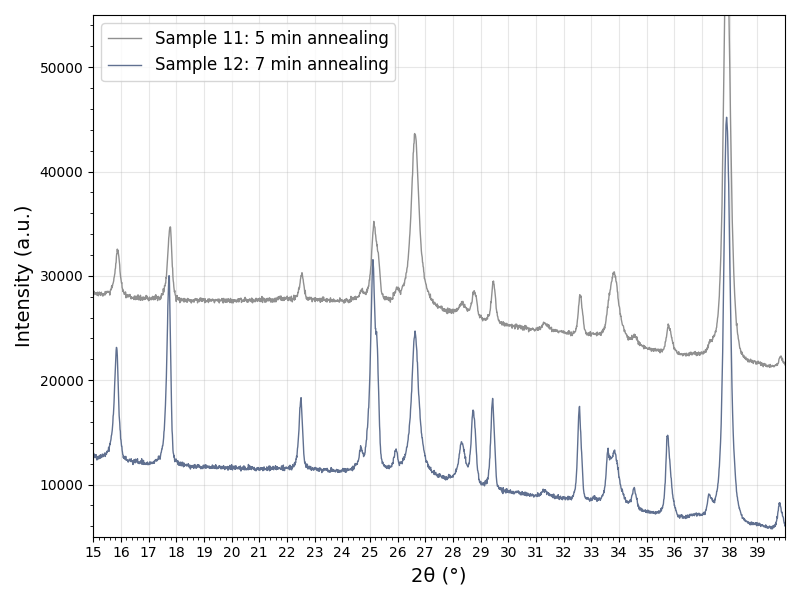

In [ ]:
# File paths to your .txt files
file1 = r"../data/raw_data/second_batch/11_25_07_4mM_5_min_annealing.xy"
file2 = r"../data/raw_data/second_batch/12_25_07_4mM_7_min_annealing.xy"



# Plot the normalized XRD spectra

plot_XRD_normalized(file1, file2, labels=["Sample 11: 5 min annealing", "Sample 12: 7 min annealing"], offset=15000, window_size=1)
                    
